# v3 亏损交易买入前特征探索

## tl;dr

- 当前 Rank4-only 稳定盈利前沿共有 **771 笔已闭环交易**，其中 **325 笔亏损（42.2%）**、446 笔盈利。
- 最稳定的差异来自**模型排序较后（Rank2 及以后）**与**股票首次进入历史交易序列**，不是某个单独价格或成交特征。Rank2+ 在后段留出期的亏损率为 **52.9%**，同期总体为 47.3%。
- “首次进入 + 前60日涨幅至少约6.8%”在留出期亏损率为 **56.2%**，但该组完整历史净利润仍为正，profit factor 为 **2.55**，因此不能直接据此剔除。
- 单独的涨幅、波动率、距高点、换手率等技术特征均未形成同等级的稳定时间外区分。下一步应预注册少量“降权”实验，而不是事后堆过滤器。

## Context & Methods

分析对象是当前活跃的 Rank4-only 稳定盈利前沿，而不是旧 Rank4-5 配置。单位是一只股票在一个信号日形成的一笔已闭环入场；净收益小于等于 0 记为亏损。

### Key Assumptions

- 只使用信号日收盘及以前可得的数据；明确排除入场日收盘、持有期价格和候选源中的未来收益字段。
- 24 笔回放末端尚未闭环的买入不进入盈亏比较。
- 前 70% 信号日期用于发现阈值，后 30% 日期作为时间外验证；阈值规则仍属于探索性关联，不是因果结论或上线门禁。

In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd() / "src"))
import runpy
import pandas as pd
import matplotlib.pyplot as plt

SNAPSHOT = Path("/Users/hernando_zhao/codex/runtime/projects/ashare-dashboard/data/artifacts/research_validation/rolling_account_execution_snapshots/shortpick-v3-execution-snapshot-067c5b83e085f95f.json.gz")
SCRIPT = Path("scripts/research-shortpick-v3-loss-preentry-features.py")
module = runpy.run_path(str(SCRIPT))
payload = module["run_analysis"](SNAPSHOT)
assert payload["status"] == "completed"
payload["artifact_id"]

'shortpick-v3-loss-preentry-feature-exploration-20260717'

## Data

### 1. Validate the replay and feature join

The exact retained execution snapshot is replayed with Rank5 disabled. The checks below verify trade grain, feature coverage, duplicate keys, open-entry exclusions, and the time split.

In [2]:
quality = payload["data_quality"]
pd.DataFrame([{
    "closed trades": quality["closed_trade_count"],
    "open entries excluded": quality["open_entry_count"],
    "duplicate trade keys": quality["trade_key_duplicate_count"],
    "feature join rate": quality["feature_join_rate"],
    "pre-signal close coverage": quality["pre_signal_close_feature_coverage_rate"],
    "time split cutoff": quality["time_split_cutoff"],
    "future leakage fields used": quality["future_field_leakage_count"],
}])

,closed trades,open entries excluded,duplicate trade keys,feature join rate,pre-signal close coverage,time split cutoff,future leakage fields used
0,769,26,0,1.0,1.0,2025-08-18,0


In [3]:
population = payload["population"]
pd.DataFrame([
    {"sample": "all", "trades": population["closed_trade_count"], "losses": population["loss_count"], "winners": population["winner_count"], "loss rate": population["loss_rate"]},
    {"sample": "discovery", "trades": population["discovery"]["trade_count"], "losses": population["discovery"]["loss_count"], "winners": population["discovery"]["winner_count"], "loss rate": population["discovery"]["loss_rate"]},
    {"sample": "validation", "trades": population["validation"]["trade_count"], "losses": population["validation"]["loss_count"], "winners": population["validation"]["winner_count"], "loss rate": population["validation"]["loss_rate"]},
])

,sample,trades,losses,winners,loss rate
0,all,769,325,444,0.422627
1,discovery,532,213,319,0.400376
2,validation,237,112,125,0.472574


## Results

### 2. Stable single-feature patterns

A pattern is marked validated only when the earlier discovery period shows at least an 8 percentage-point loss-vs-winner prevalence gap and the later period retains a positive gap with at least 5% loss-rate lift. Rank weight is a deterministic restatement of model rank, so those two rows are one economic finding rather than two independent signals.

In [4]:
single_rows = []
for row in payload["validated_single_feature_patterns"]:
    if not row["validated"]:
        continue
    single_rows.append({
        "feature": row["feature"],
        "condition": f"{row['direction']} {row['threshold']:.4g}",
        "all trades": row["all_history"]["pattern_count"],
        "all loss rate": row["all_history"]["loss_rate"],
        "validation trades": row["validation"]["pattern_count"],
        "validation loss rate": row["validation"]["loss_rate"],
        "validation baseline": row["validation"]["baseline_loss_rate"],
        "validation prevalence gap": row["validation"]["prevalence_gap"],
        "all net PnL": row["all_history"]["net_pnl_cny"],
        "profit factor": row["all_history"]["profit_factor"],
    })
single_table = pd.DataFrame(single_rows)
single_table

,feature,condition,all trades,all loss rate,validation trades,validation loss rate,validation baseline,validation prevalence gap,all net PnL,profit factor
0,rank_weight_multiplier,low 0.9,432,0.481481,155,0.529032,0.472574,0.148143,176609.2875,3.343219
1,prior_same_symbol_entry_count,low 0,398,0.489950,127,0.527559,0.472574,0.118214,309885.8445,3.037106
2,prior_same_symbol_entry_count_30d,low 0,549,0.462659,176,0.505682,0.472574,0.098643,421295.4690,3.309389


### 3. Loss prevalence versus winner prevalence

The chart compares how often each pattern appears among all losing trades versus all winning trades. A wider gap means the pattern is more characteristic of losses, but it does not imply negative expected value.

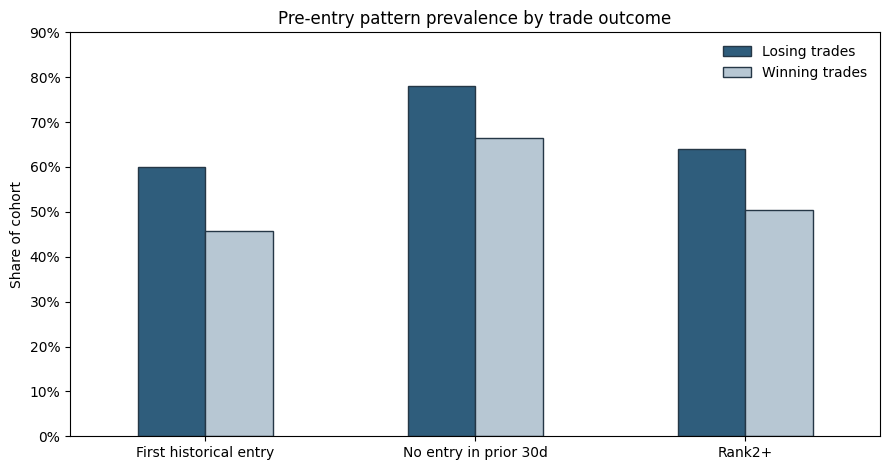

In [5]:
patterns = []
selected_specs = [
    ("Rank2+", "rank_weight_multiplier"),
    ("First historical entry", "prior_same_symbol_entry_count"),
    ("No entry in prior 30d", "prior_same_symbol_entry_count_30d"),
]
for label, feature in selected_specs:
    row = next(r for r in payload["validated_single_feature_patterns"] if r["feature"] == feature)
    patterns.extend([
        {"pattern": label, "cohort": "Losing trades", "prevalence": row["all_history"]["loss_prevalence"]},
        {"pattern": label, "cohort": "Winning trades", "prevalence": row["all_history"]["winner_prevalence"]},
    ])
plot_frame = pd.DataFrame(patterns)
pivot = plot_frame.pivot(index="pattern", columns="cohort", values="prevalence")
ax = pivot[["Losing trades", "Winning trades"]].plot(kind="bar", figsize=(9, 4.8), color=["#2F5D7C", "#B7C7D3"], edgecolor="#253746")
ax.set_title("Pre-entry pattern prevalence by trade outcome")
ax.set_ylabel("Share of cohort")
ax.set_xlabel("")
ax.set_ylim(0, 0.9)
ax.yaxis.set_major_formatter(lambda value, _position: f"{value:.0%}")
ax.legend(frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4. The strongest price interaction is not safe to filter

The strongest time-validated price interaction is a first-time stock whose prior 60-day rise is at least about 6.8%. It has a higher loss rate, but its large winners still leave the group strongly profitable. This is evidence for a sizing experiment, not a deletion rule.

In [6]:
pair = next(
    row for row in payload["validated_pair_patterns"]
    if {condition["feature"] for condition in row["conditions"]} == {"prior_same_symbol_entry_count", "pre_return_60d"}
)
pd.DataFrame([{
    "pattern": "first entry + pre-60d return >= 6.8%",
    "all trades": pair["all_history"]["pattern_count"],
    "all loss rate": pair["all_history"]["loss_rate"],
    "validation trades": pair["validation"]["pattern_count"],
    "validation loss rate": pair["validation"]["loss_rate"],
    "validation baseline": pair["validation"]["baseline_loss_rate"],
    "net PnL CNY": pair["all_history"]["net_pnl_cny"],
    "profit factor": pair["all_history"]["profit_factor"],
}])

,pattern,all trades,all loss rate,validation trades,validation loss rate,validation baseline,net PnL CNY,profit factor
0,first entry + pre-60d return >= 6.8%,260,0.526923,96,0.5625,0.472574,202853.472,2.552252


### 5. Standalone technical features are weak separators

The table ranks univariate separation. After false-discovery control, the reliable rows are model-rank or repeat-exposure variables. Price/volume rows have AUCs close to 0.5, and their directions usually do not remain stable out of time.

In [7]:
stats_rows = []
for row in payload["feature_statistics"][:15]:
    stats_rows.append({
        "feature": row["feature"],
        "loss median": row["loss_median"],
        "winner median": row["winner_median"],
        "separation AUC": row["separation_auc"],
        "FDR q": row["fdr_q"],
        "direction stable OOT": row["direction_stable_out_of_time"],
    })
pd.DataFrame(stats_rows)

,feature,loss median,winner median,separation AUC,FDR q,direction stable OOT
0,rank_weight_multiplier,0.600000,0.900000,0.588243,0.000589,True
1,days_since_prior_same_symbol_loss,173.000000,117.000000,0.586346,0.192046,False
2,rank,2.000000,2.000000,0.575232,0.001984,False
3,prior_same_symbol_entry_count,0.000000,1.000000,0.574432,0.001984,True
4,days_since_prior_same_symbol_signal,21.500000,8.000000,0.565991,0.155753,True
5,prior_same_symbol_entry_count_30d,0.000000,0.000000,0.560627,0.003234,False
6,prior_closed_same_symbol_count,0.000000,0.000000,0.548399,0.040642,False
7,pre_return_acceleration_5v20,0.031544,0.022872,0.546542,0.150251,False
8,turnover_rate_percentile,0.673090,0.510133,0.544612,0.155753,False
9,pre_distance_high_60d,-0.007962,-0.014669,0.538728,0.210430,False


## Takeaways

1. **Lower-ranked picks are genuinely less reliable.** Rank2+ captures 64.0% of losses versus 50.4% of winners across the full history; the gap remains 14.8 percentage points in the later validation period.
2. **First-time appearances are riskier than repeat leaders.** Stocks with no prior strategy entry capture 60.0% of losses versus 45.5% of winners, consistent across calendar years. This may reflect false breakouts at first appearance while persistent winners are selected repeatedly.
3. **A hot first appearance deserves a sizing test, not a ban.** First entry plus strong 60-day momentum reaches a 56.2% validation loss rate, but the group remains profitable with a 2.55 profit factor. Hard filtering would likely remove important right-tail winners.
4. **No standalone technical threshold is ready.** The next controlled experiment should compare modest Rank2/3 or first-entry scaling against the unchanged Rank4-only baseline, with total return, drawdown, negative months, skipped orders and winner dependency all reported. No live rule should change from this notebook alone.